# Phase 3: General-Purpose Siamese Network (V2.1 — GPU + Two-Phase Training)

**Objective:** Train a robust, general-purpose signature verification model across all 55 signers.

**V2.1 Improvements:**
- **GPU acceleration** with Mixed Precision (AMP) for RTX 4050
- **Two-phase training**: Phase 1 trains projection head only (backbone frozen), Phase 2 fine-tunes everything with differential learning rates
- Stricter margin (0.3) to push forgery scores further from genuine
- More training pairs (80 per type) and larger batch size (32)
- 50 total epochs with patience=12 early stopping

In [3]:
import os
import glob
import re
import json
import random
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from sklearn.metrics import roc_auc_score, roc_curve

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print('matplotlib not available, skipping visualizations')

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

# ---- GPU Detection ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

if DEVICE.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB VRAM)')
    torch.backends.cudnn.benchmark = True
else:
    print('='*60)
    print('WARNING: CUDA NOT DETECTED! Training will be VERY SLOW.')
    print('Make sure the kernel uses a CUDA-enabled PyTorch.')
    print('='*60)

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (6.0 GB VRAM)


### 1. Model Architecture: ResNet18 + Projection Head

```
Input (224x224x3) -> ResNet18 backbone (frozen in Phase 1)
  -> 512-dim -> Linear(256) -> BN -> ReLU -> Dropout(0.3)
  -> Linear(128) -> L2-Norm -> 128-dim embedding
```

In [4]:
class SiameseNetwork(nn.Module):
    '''Siamese Network: ResNet18 backbone + projection head.
    Produces L2-normalized 128-dim embeddings for cosine similarity.
    '''
    def __init__(self, embedding_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, embedding_dim),
        )

    def forward_once(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.projection(x)
        x = F.normalize(x, p=2, dim=1)
        return x

    def forward(self, x1, x2=None):
        e1 = self.forward_once(x1)
        if x2 is None:
            return e1
        e2 = self.forward_once(x2)
        return e1, e2

model = SiameseNetwork(embedding_dim=128).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'SiameseNetwork initialized: {total_params:,} parameters on {DEVICE}')

SiameseNetwork initialized: 11,341,248 parameters on cuda


### 2. Robust Preprocessing Pipeline

- **Otsu binarization** for stroke isolation
- **Morphological closing** to connect nearby strokes
- **Merged bounding box** from ALL contours (captures disconnected strokes)
- **Aspect-ratio preserving resize** (pad to square, then resize to 224x224)

Preprocessed: (224, 224, 3), range [0, 255]


Preprocessed: (224, 224, 3), range [0, 255]


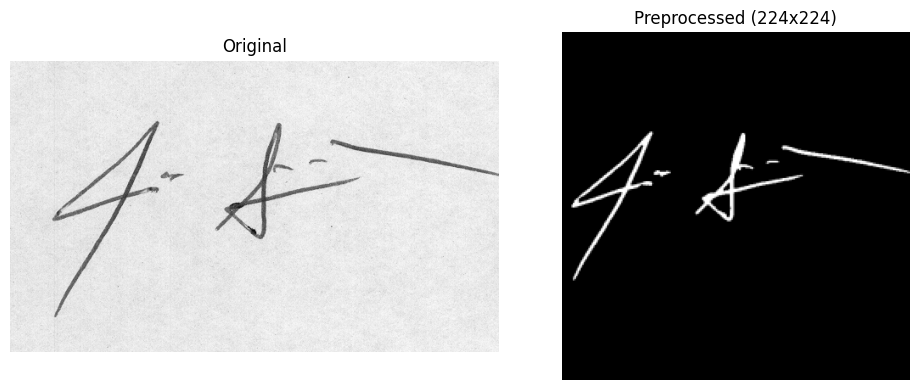

In [5]:
def preprocess_signature(image_path):
    '''Preprocess a signature image: isolate strokes, crop, pad, resize.
    Returns a 224x224x3 numpy array (uint8).
    '''
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'Could not read image: {image_path}')

    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) > 50]

    if contours:
        all_points = np.vstack(contours)
        x, y, w, h = cv2.boundingRect(all_points)
        pad = 15
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(img.shape[1], x + w + pad)
        y2 = min(img.shape[0], y + h + pad)
        cropped = binary[y1:y2, x1:x2]
    else:
        cropped = binary

    ch, cw = cropped.shape
    if ch == 0 or cw == 0:
        cropped = binary
        ch, cw = cropped.shape
    max_dim = max(ch, cw)
    padded = np.zeros((max_dim, max_dim), dtype=np.uint8)
    y_off = (max_dim - ch) // 2
    x_off = (max_dim - cw) // 2
    padded[y_off:y_off+ch, x_off:x_off+cw] = cropped

    resized = cv2.resize(padded, (224, 224), interpolation=cv2.INTER_AREA)
    rgb = np.stack([resized, resized, resized], axis=-1)
    return rgb

# Quick test
test_path = glob.glob('../data/raw/signatures/full_org/original_1_1.png')[0]
test_img = preprocess_signature(test_path)
print(f'Preprocessed: {test_img.shape}, range [{test_img.min()}, {test_img.max()}]')

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cv2.imread(test_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    axes[0].set_title('Original')
    axes[1].imshow(test_img[:,:,0], cmap='gray')
    axes[1].set_title('Preprocessed (224x224)')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

### 3. Multi-Identity Pair Generation

Three pair types per signer:
- **Positive** (label=1): genuine vs genuine, same signer
- **Hard negative** (label=-1): genuine vs skilled forgery, same signer
- **Easy negative** (label=-1): genuine from different signers

In [6]:
class SiameseSignatureDataset(Dataset):
    '''Generates genuine/forgery pairs for multi-identity Siamese training.'''

    def __init__(self, genuine_by_signer, forgery_by_signer, signer_ids,
                 pairs_per_type=50, transform=None):
        self.transform = transform
        self.image_pairs = []
        self.labels = []

        for sid in signer_ids:
            gen = genuine_by_signer[sid]
            forg = forgery_by_signer.get(sid, [])
            others = [s for s in signer_ids if s != sid]

            # Positive: genuine vs genuine (same signer)
            n_pos = min(pairs_per_type, len(gen) * (len(gen) - 1) // 2)
            for _ in range(n_pos):
                i, j = random.sample(range(len(gen)), 2)
                self.image_pairs.append((gen[i], gen[j]))
                self.labels.append(1.0)

            # Hard negative: genuine vs forgery (same signer)
            if forg:
                n_hard = min(pairs_per_type, len(gen) * len(forg))
                for _ in range(n_hard):
                    self.image_pairs.append((random.choice(gen), random.choice(forg)))
                    self.labels.append(-1.0)

            # Easy negative: different signers
            n_easy = pairs_per_type // 2
            for _ in range(n_easy):
                other_sid = random.choice(others)
                self.image_pairs.append(
                    (random.choice(gen), random.choice(genuine_by_signer[other_sid]))
                )
                self.labels.append(-1.0)

        n_pos = self.labels.count(1.0)
        n_neg = self.labels.count(-1.0)
        print(f'Dataset: {len(self)} pairs | Positive: {n_pos} | Negative: {n_neg}')

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        path1, path2 = self.image_pairs[idx]
        label = self.labels[idx]
        img1 = preprocess_signature(path1)
        img2 = preprocess_signature(path2)
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        return img1, img2, torch.tensor(label, dtype=torch.float32)

print('SiameseSignatureDataset ready.')

SiameseSignatureDataset ready.


### 4. Data Loading & Configuration

- 80/20 signer-level split (no data leakage)
- 80 pairs per type for training, 60 for validation
- Batch size 32 (optimized for RTX 4050)
- Augmentation: rotation, perspective, blur, jitter, affine

In [7]:
# ---- Parse dataset ----
genuine_by_signer = defaultdict(list)
forgery_by_signer = defaultdict(list)

for path in sorted(glob.glob('../data/raw/signatures/full_org/original_*.png')):
    match = re.search(r'original_(\d+)_(\d+)\.png', os.path.basename(path))
    if match:
        genuine_by_signer[int(match.group(1))].append(path)

for path in sorted(glob.glob('../data/raw/signatures/full_forg/forgeries_*.png')):
    match = re.search(r'forgeries_(\d+)_(\d+)\.png', os.path.basename(path))
    if match:
        forgery_by_signer[int(match.group(1))].append(path)

all_signers = sorted(genuine_by_signer.keys())
print(f'Signers: {len(all_signers)}')
print(f'Genuine: {sum(len(v) for v in genuine_by_signer.values())} images')
print(f'Forgery: {sum(len(v) for v in forgery_by_signer.values())} images')

# ---- Signer-level split ----
random.shuffle(all_signers)
split_idx = int(len(all_signers) * 0.8)
train_signers = all_signers[:split_idx]
val_signers = all_signers[split_idx:]
print(f'Train: {len(train_signers)} signers | Val: {len(val_signers)} signers')

# ---- Transforms (more aggressive augmentation) ----
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=12),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.4),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ---- Datasets & Loaders ----
train_dataset = SiameseSignatureDataset(
    genuine_by_signer, forgery_by_signer, train_signers,
    pairs_per_type=80, transform=train_transform
)
val_dataset = SiameseSignatureDataset(
    genuine_by_signer, forgery_by_signer, val_signers,
    pairs_per_type=60, transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_dataset)} pairs, {len(train_loader)} batches')
print(f'Val:   {len(val_dataset)} pairs, {len(val_loader)} batches')

Signers: 55
Genuine: 1320 images
Forgery: 1320 images
Train: 44 signers | Val: 11 signers
Dataset: 8800 pairs | Positive: 3520 | Negative: 5280
Dataset: 1650 pairs | Positive: 660 | Negative: 990
Train: 8800 pairs, 275 batches
Val:   1650 pairs, 52 batches


### 5. Two-Phase Training with Mixed Precision

**Phase 1 (10 epochs):** Backbone FROZEN. Only the projection head learns signature-specific embeddings.
This prevents catastrophic forgetting of ImageNet features while the projection head warms up.

**Phase 2 (40 epochs):** Backbone UNFROZEN with differential learning rates:
- Backbone: `5e-5` (gentle fine-tuning)
- Projection head: `3e-4` (continues aggressive learning)

Both phases use **CosineEmbeddingLoss(margin=0.3)** — stricter than V2's 0.5 margin,
forcing the model to push forgery scores well below 0.3 cosine similarity.

**Mixed Precision (AMP)** is enabled on CUDA for ~2x speedup.

In [10]:
os.makedirs('../models', exist_ok=True)

use_amp = (DEVICE.type == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=use_amp) if use_amp else torch.amp.GradScaler('cpu')
criterion = nn.CosineEmbeddingLoss(margin=0.3)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'phase': []}

def run_epoch(loader, training=True):
    '''Run one epoch of training or validation.'''
    model.train() if training else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    device_type = 'cuda' if DEVICE.type == 'cuda' else 'cpu'
    with ctx:
        for img1, img2, labels in loader:
            img1 = img1.to(DEVICE, non_blocking=True)
            img2 = img2.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad()

            with torch.amp.autocast(device_type, enabled=use_amp):
                emb1, emb2 = model(img1, img2)
                loss = criterion(emb1, emb2, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
    return total_loss / len(loader)

# ============================================================
# PHASE 1: Train Projection Head Only (Backbone Frozen)
# ============================================================
print('=' * 60)
print('PHASE 1: Projection Head Training (backbone frozen)')
print('=' * 60)

for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.projection.parameters(), lr=0.001, weight_decay=1e-4)
PHASE1_EPOCHS = 10

for epoch in range(PHASE1_EPOCHS):
    t_loss = run_epoch(train_loader, training=True)
    v_loss = run_epoch(val_loader, training=False)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['phase'].append(1)

    marker = ''
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), '../models/forensic_signature_v2.pt')
        marker = ' << best'

    print(f'P1 [{epoch+1:02d}/{PHASE1_EPOCHS}] '
          f'Train: {t_loss:.4f} | Val: {v_loss:.4f}{marker}')

print(f'Phase 1 done. Best val loss: {best_val_loss:.4f}\n')

# ============================================================
# PHASE 2: Full Fine-tuning (All Layers Unfrozen)
# ============================================================
print('=' * 60)
print('PHASE 2: Full Fine-tuning (differential LR)')
print('=' * 60)

for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.Adam([
    {'params': model.features.parameters(), 'lr': 5e-5},
    {'params': model.projection.parameters(), 'lr': 3e-4},
], weight_decay=1e-4)

PHASE2_EPOCHS = 40
patience = 12
patience_counter = 0
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6
)

for epoch in range(PHASE2_EPOCHS):
    t_loss = run_epoch(train_loader, training=True)
    v_loss = run_epoch(val_loader, training=False)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['phase'].append(2)

    marker = ''
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), '../models/forensic_signature_v2.pt')
        marker = ' << best'
    else:
        patience_counter += 1

    lr_f = optimizer.param_groups[0]['lr']
    lr_p = optimizer.param_groups[1]['lr']
    print(f'P2 [{epoch+1:02d}/{PHASE2_EPOCHS}] '
          f'Train: {t_loss:.4f} | Val: {v_loss:.4f} | '
          f'LR: {lr_f:.6f}/{lr_p:.6f}{marker}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\nTraining complete! Best val loss: {best_val_loss:.4f}')

PHASE 1: Projection Head Training (backbone frozen)
P1 [01/10] Train: 0.1827 | Val: 0.2281 << best
P1 [02/10] Train: 0.1732 | Val: 0.2353
P1 [03/10] Train: 0.1693 | Val: 0.2384
P1 [04/10] Train: 0.1656 | Val: 0.2417
P1 [05/10] Train: 0.1661 | Val: 0.2303
P1 [06/10] Train: 0.1609 | Val: 0.2445
P1 [07/10] Train: 0.1578 | Val: 0.2330
P1 [08/10] Train: 0.1624 | Val: 0.2361
P1 [09/10] Train: 0.1534 | Val: 0.2322
P1 [10/10] Train: 0.1509 | Val: 0.2325
Phase 1 done. Best val loss: 0.2281

PHASE 2: Full Fine-tuning (differential LR)
P2 [01/40] Train: 0.1239 | Val: 0.2038 | LR: 0.000050/0.000300 << best
P2 [02/40] Train: 0.0794 | Val: 0.2038 | LR: 0.000050/0.000298 << best
P2 [03/40] Train: 0.0549 | Val: 0.2157 | LR: 0.000049/0.000296
P2 [04/40] Train: 0.0475 | Val: 0.2103 | LR: 0.000049/0.000293
P2 [05/40] Train: 0.0397 | Val: 0.1941 | LR: 0.000048/0.000289 << best
P2 [06/40] Train: 0.0351 | Val: 0.1999 | LR: 0.000047/0.000284
P2 [07/40] Train: 0.0302 | Val: 0.2149 | LR: 0.000046/0.000278
P2 [

### 6. Forensic Performance Audit & Threshold Calibration

Evaluate on validation signers (completely unseen during training):
- **ROC-AUC** target: > 0.90
- **EER** target: < 15%
- **Optimal threshold** via Youden's J statistic

Genuine pairs: 660 | Forgery pairs: 990

Score Distribution:
  Genuine  - Mean: 0.7492, Min: -0.3148, Max: 0.9950
  Forgery  - Mean: 0.2655, Min: -0.7655, Max: 0.9904

ROC-AUC: 0.8374
EER: 0.2298 at threshold: 0.6475
Optimal Threshold (Youden J): 0.6005
  TPR: 0.8182, FPR: 0.2545

Score separation gap: 0.4836

ROC-AUC: 0.8374  NEEDS IMPROVEMENT
EER:     0.2298  NEEDS IMPROVEMENT
Gap:     0.4836  PASS


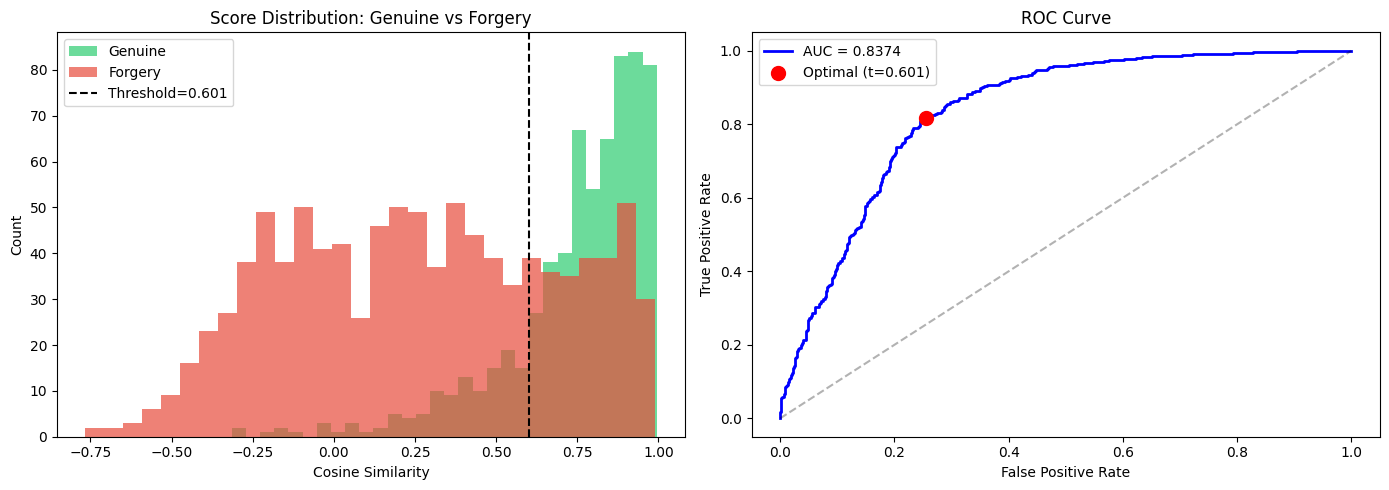

Plots saved to models/evaluation_plots.png


In [11]:
# Load best model
model.load_state_dict(torch.load(
    '../models/forensic_signature_v2.pt', map_location=DEVICE, weights_only=True
))
model.eval()

genuine_scores = []
forgery_scores = []

device_type = 'cuda' if DEVICE.type == 'cuda' else 'cpu'
with torch.no_grad():
    for img1, img2, labels in val_loader:
        img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
        with torch.amp.autocast(device_type, enabled=use_amp):
            emb1, emb2 = model(img1, img2)
        sims = F.cosine_similarity(emb1, emb2).cpu().numpy()
        for sim, label in zip(sims, labels.numpy()):
            if label == 1.0:
                genuine_scores.append(float(sim))
            else:
                forgery_scores.append(float(sim))

print(f'Genuine pairs: {len(genuine_scores)} | Forgery pairs: {len(forgery_scores)}')
print(f'\nScore Distribution:')
print(f'  Genuine  - Mean: {np.mean(genuine_scores):.4f}, '
      f'Min: {np.min(genuine_scores):.4f}, Max: {np.max(genuine_scores):.4f}')
print(f'  Forgery  - Mean: {np.mean(forgery_scores):.4f}, '
      f'Min: {np.min(forgery_scores):.4f}, Max: {np.max(forgery_scores):.4f}')

# ---- ROC-AUC ----
all_scores = genuine_scores + forgery_scores
all_labels = [1] * len(genuine_scores) + [0] * len(forgery_scores)
auc = roc_auc_score(all_labels, all_scores)
print(f'\nROC-AUC: {auc:.4f}')

# ---- EER ----
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
eer_threshold = float(thresholds[eer_idx])
print(f'EER: {eer:.4f} at threshold: {eer_threshold:.4f}')

# ---- Optimal threshold (Youden J) ----
j_scores = tpr - fpr
opt_idx = np.argmax(j_scores)
optimal_threshold = float(thresholds[opt_idx])
print(f'Optimal Threshold (Youden J): {optimal_threshold:.4f}')
print(f'  TPR: {tpr[opt_idx]:.4f}, FPR: {fpr[opt_idx]:.4f}')

gap = np.mean(genuine_scores) - np.mean(forgery_scores)
print(f'\nScore separation gap: {gap:.4f}')

# ---- Status ----
print(f'\n{"=" * 40}')
print(f'ROC-AUC: {auc:.4f}  {"PASS" if auc > 0.90 else "NEEDS IMPROVEMENT"}')
print(f'EER:     {eer:.4f}  {"PASS" if eer < 0.15 else "NEEDS IMPROVEMENT"}')
print(f'Gap:     {gap:.4f}  {"PASS" if gap > 0.40 else "NEEDS IMPROVEMENT"}')
print(f'{"=" * 40}')

# ---- Visualize ----
if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(genuine_scores, bins=30, alpha=0.7, label='Genuine', color='#2ecc71')
    axes[0].hist(forgery_scores, bins=30, alpha=0.7, label='Forgery', color='#e74c3c')
    axes[0].axvline(x=optimal_threshold, color='black', linestyle='--',
                    label=f'Threshold={optimal_threshold:.3f}')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Score Distribution: Genuine vs Forgery')
    axes[0].legend()

    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[1].scatter(fpr[opt_idx], tpr[opt_idx], c='red', s=100, zorder=5,
                    label=f'Optimal (t={optimal_threshold:.3f})')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../models/evaluation_plots.png', dpi=150)
    plt.show()
    print('Plots saved to models/evaluation_plots.png')

### 7. Export Model & Configuration

Save model weights, optimal threshold, and metrics for the FastAPI backend.

In [12]:
config = {
    'model_version': 'v2.1',
    'architecture': 'SiameseNetwork_ResNet18_128dim',
    'embedding_dim': 128,
    'optimal_threshold': optimal_threshold,
    'eer_threshold': eer_threshold,
    'eer': float(eer),
    'roc_auc': float(auc),
    'train_signers': len(train_signers),
    'val_signers': len(val_signers),
    'genuine_score_mean': float(np.mean(genuine_scores)),
    'forgery_score_mean': float(np.mean(forgery_scores)),
    'score_gap': float(gap),
    'training': {
        'phase1_epochs': PHASE1_EPOCHS,
        'phase2_epochs': len([p for p in history['phase'] if p == 2]),
        'margin': 0.3,
        'batch_size': 32,
        'device': str(DEVICE),
    }
}

with open('../models/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

with open('../models/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Model config saved to models/model_config.json')
print(json.dumps(config, indent=2))

print('\nAll artifacts saved:')
print('  - models/forensic_signature_v2.pt')
print('  - models/model_config.json')
print('  - models/training_history.json')
if HAS_MPL:
    print('  - models/evaluation_plots.png')

Model config saved to models/model_config.json
{
  "model_version": "v2.1",
  "architecture": "SiameseNetwork_ResNet18_128dim",
  "embedding_dim": 128,
  "optimal_threshold": 0.6005434989929199,
  "eer_threshold": 0.6474528312683105,
  "eer": 0.22979797979797983,
  "roc_auc": 0.8374242424242424,
  "train_signers": 44,
  "val_signers": 11,
  "genuine_score_mean": 0.7491669951938092,
  "forgery_score_mean": 0.2655479965124731,
  "score_gap": 0.4836189986813362,
  "training": {
    "phase1_epochs": 10,
    "phase2_epochs": 17,
    "margin": 0.3,
    "batch_size": 32,
    "device": "cuda"
  }
}

All artifacts saved:
  - models/forensic_signature_v2.pt
  - models/model_config.json
  - models/training_history.json
  - models/evaluation_plots.png
